# Environment Configuration



 Load the necessary packages

In [5]:
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pickle

Load and environment configuration

In [6]:
from pathlib import Path
import os
import random
import numpy as np

#===================================
# project configuration
#===================================

# Routes

#project root directory

BASE         = Path.cwd().parent

# project directories
DATA         = BASE / "data"
PROCESSED_DATA = DATA / "processed"
FIGURES = BASE / "figures"
RESULTS = BASE / "results"
MODELS = BASE / "models"


RANDOM_STATE = 42

#reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Create directories if they do not exist
for directory in [
    PROCESSED_DATA,
    FIGURES,
    RESULTS,
    MODELS
]:
    directory.mkdir(parents=True, exist_ok=True)

# ============================================================
# CONFIGURATION CHECK
# ============================================================

print("Configuration ready\n")

print(f"BASE          : {BASE}")
print(f"DATA          : {DATA}")
print(f"PROCESSED_DATA: {PROCESSED_DATA}")
print(f"FIGURES       : {FIGURES}")
print(f"RESULTS       : {RESULTS}")
print(f"MODELS        : {MODELS}")
print(f"RANDOM_STATE  : {RANDOM_STATE}")


Configuration ready

BASE          : /
DATA          : /data
PROCESSED_DATA: /data/processed
FIGURES       : /figures
RESULTS       : /results
MODELS        : /models
RANDOM_STATE  : 42


# 2. Load Dataset

In [4]:
!pip install -q ucimlrepo

In [7]:
from ucimlrepo import fetch_ucirepo

auto_mpg = fetch_ucirepo(id=9)

X = auto_mpg.data.features
y = auto_mpg.data.targets

print(auto_mpg.variables[['name', 'role', 'type']])

           name     role         type
0  displacement  Feature   Continuous
1           mpg   Target   Continuous
2     cylinders  Feature      Integer
3    horsepower  Feature   Continuous
4        weight  Feature   Continuous
5  acceleration  Feature   Continuous
6    model_year  Feature      Integer
7        origin  Feature      Integer
8      car_name       ID  Categorical


Create the working dataframe

In [8]:
df = X.copy()
df['mpg'] = y['mpg'].values

# Separate car_name for EDA purposes only
car_names = auto_mpg.data.ids

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (398, 8)
Columns: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'mpg']


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0


In [9]:
#we view the columns in X in correspondence with the features
print("Columns in X (features):")
print(X.columns.tolist())

#we view the columns in Y in correspondence with the targets
print("\nColumns in y (targets):")
print(y.columns.tolist())

Columns in X (features):
['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']

Columns in y (targets):
['mpg']


# 3.- An initial revision of the dataset

In [10]:
#we view the dimensions
print(" Dimensions ")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")

 Dimensions 
Rows: 398  |  Columns: 8


In [11]:
#we view the data type
print("Type of data")
print(df.dtypes)


Type of data
displacement    float64
cylinders         int64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
mpg             float64
dtype: object


In [12]:
# null values
print("Null values per column")
null = df.isnull().sum()
print(null[null > 0] if null.sum() > 0 else "Without null values")
print(f"Total nulls: {null.sum()}")


Null values per column
horsepower    6
dtype: int64
Total nulls: 6


In [13]:
# we view the descriptives statics
print("Estatics descriptives")
df.describe().round(2)

Estatics descriptives


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,398.00,398.00,392.00,398.00,398.00,398.00,398.00,398.00
mean,193.43,5.45,104.47,2970.42,15.57,76.01,1.57,23.51
std,104.27,1.70,38.49,846.84,2.76,3.70,0.80,7.82
min,68.00,3.00,46.00,1613.00,8.00,70.00,1.00,9.00
25%,104.25,4.00,75.00,2223.75,13.82,73.00,1.00,17.50
50%,148.50,4.00,93.50,2803.50,15.50,76.00,1.00,23.00
75%,262.00,8.00,126.00,3608.00,17.18,79.00,2.00,29.00
max,455.00,8.00,230.00,5140.00,24.80,82.00,3.00,46.60


**Observation:**
+ The variable `origin` with values 1,2,3 represents origin categories (USA, Europe, Japon)

+ The variable `horsepower` has six null values

+ The dataset variables have distinct ranges of values, hence, scaling of variables is necessary.



# 4.- Preprocessing
## 4.1.- Missing values treatment

The six missing values will be imputed with the median, given that the variable represents a positively asymmetric distribution with outliers on the upper range. The median is a robust estimator in this context.



In [14]:
average   = df['horsepower'].mean()
median = df['horsepower'].median()

print(f"Average:      {average:.1f} HP")
print(f"Median:    {median:.1f} HP")
print(f"Diference: {abs(average - median):.1f} HP")

extreme_cars = (df['horsepower'] > 150).sum()
print(f"Cars with > 150 HP (pull the average): {extreme_cars}")

Average:      104.5 HP
Median:    93.5 HP
Diference: 11.0 HP
Cars with > 150 HP (pull the average): 45


In [15]:
print(f"Missing before: {df['horsepower'].isnull().sum()}")
median = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(median)
print(f"Missing after:  {df['horsepower'].isnull().sum()}")
print(f"Median used:   {median:.1f}")

# Verify that no missing values remain in the entire DataFrame
print(f"Total missing in the dataset: {df.isnull().sum().sum()}")

Missing before: 6
Missing after:  0
Median used:   93.5
Total missing in the dataset: 0


## 4.2 Codification of the variable `origin`

+ obs: the variable `origin` have three codifications: $1 = \text{USA}$, $2 = \text{Europe}$ and $3 =  \text{Japon}$.

+ We used `get_dummies` whit `drop_firs = True`.


In [16]:
print("Unique values of origin before:", df['origin'].unique())
print("Distribution:")
print(df['origin'].value_counts())

df = pd.get_dummies(df, columns=['origin'], drop_first=True, dtype=int)

print(f"\nColumns after encoding:")
print(list(df.columns))

Unique values of origin before: [1 3 2]
Distribution:
origin
1    249
3     79
2     70
Name: count, dtype: int64

Columns after encoding:
['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'mpg', 'origin_2', 'origin_3']


The variable `origin` is encoded using one-hot encoding with `drop_first = True`, generating two dummy variables. The reference category (USA) is inferred implicitly when both variables are zero, avoiding multicollinearity.

# 5.- Exproratory Data Analysis (EDA)

We view the distribution of MPG

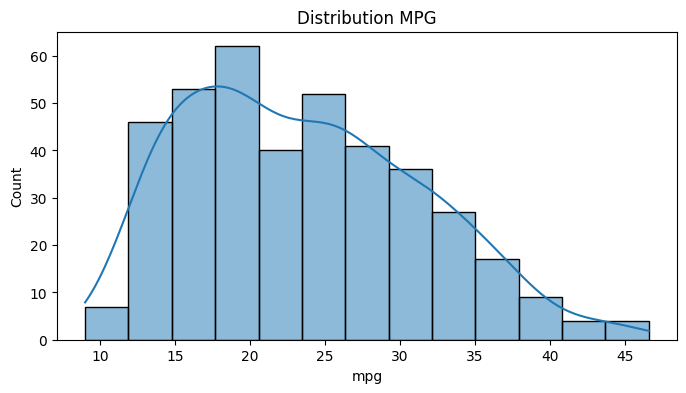

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(df["mpg"], kde=True)
plt.title("Distribution MPG")

plt.show()

We view the relationship beetwen the variables most correlated with `mpg` using scatter plots.

<Axes: xlabel='weight', ylabel='mpg'>

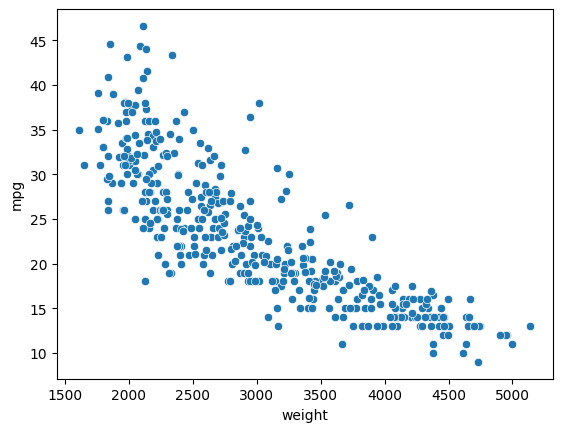

In [18]:
#relationship with the variable weight
sns.scatterplot(
    data=df,
    x="weight",
    y="mpg"
)

<Axes: xlabel='horsepower', ylabel='mpg'>

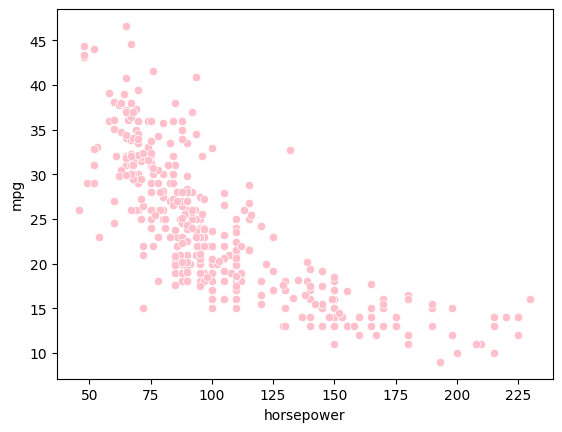

In [19]:
#relationship with the variable hosepower
sns.scatterplot(
    data=df,
    x="horsepower",
    y="mpg",
    color='pink'
)

<Axes: xlabel='displacement', ylabel='mpg'>

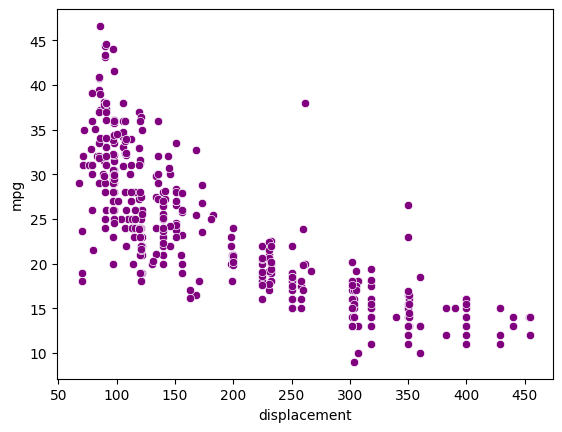

In [20]:
#relationship with the variable displacement
sns.scatterplot(
    data=df,
    x="displacement",
    y="mpg",
    color='purple'
)

We made a boxplot for detect outliers.

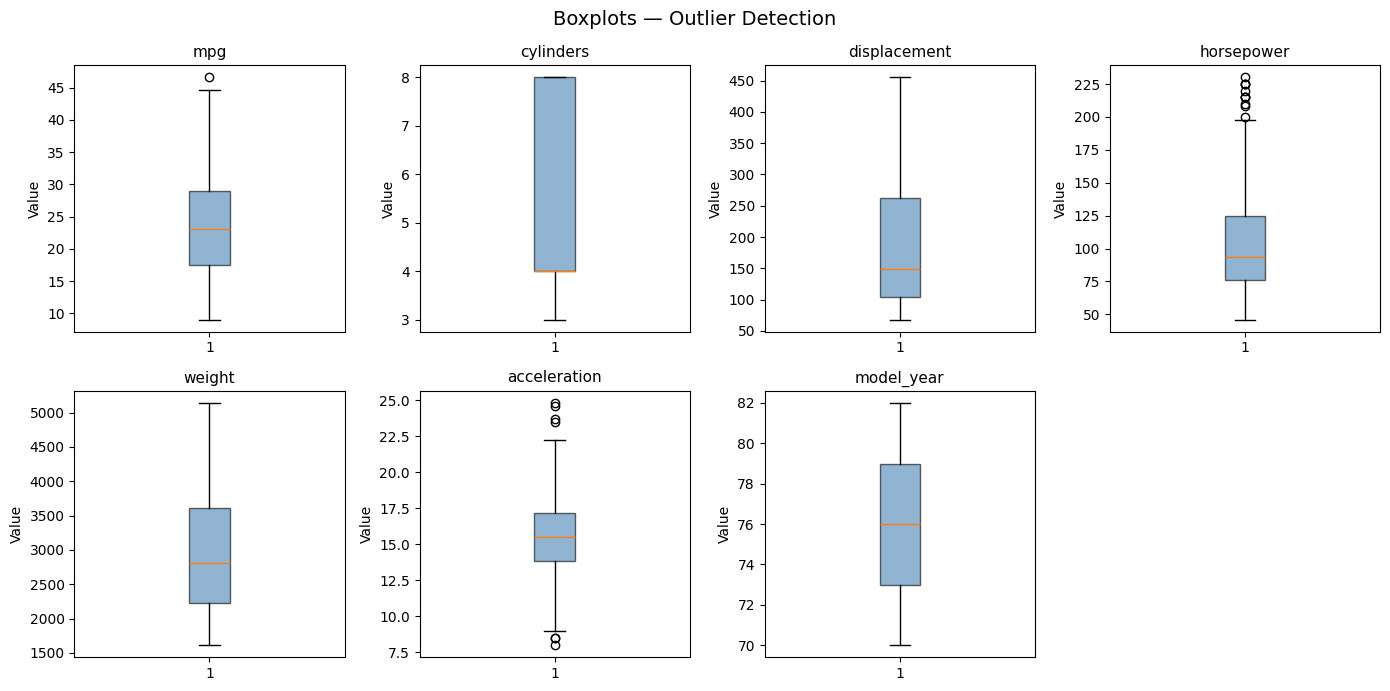

In [21]:
columnas = ['mpg', 'cylinders', 'displacement', 'horsepower',
            'weight', 'acceleration', 'model_year']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(columnas):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value')

axes[-1].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=14)
plt.tight_layout()
#plt.savefig(f'{PROJECT}/figures/boxplots.png', bbox_inches='tight')
plt.show()

6.- Division train/test

In [22]:
features = [col for col in df.columns if col != 'mpg']
target   = 'mpg'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training: {X_train.shape}")
print(f"Testing:  {X_test.shape}")

Training: (318, 8)
Testing:  (80, 8)


Save the clean data unscaled

In [23]:
# Train and test unscaled
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

X_train_raw['mpg'] = y_train.values
X_test_raw['mpg']  = y_test.values